sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


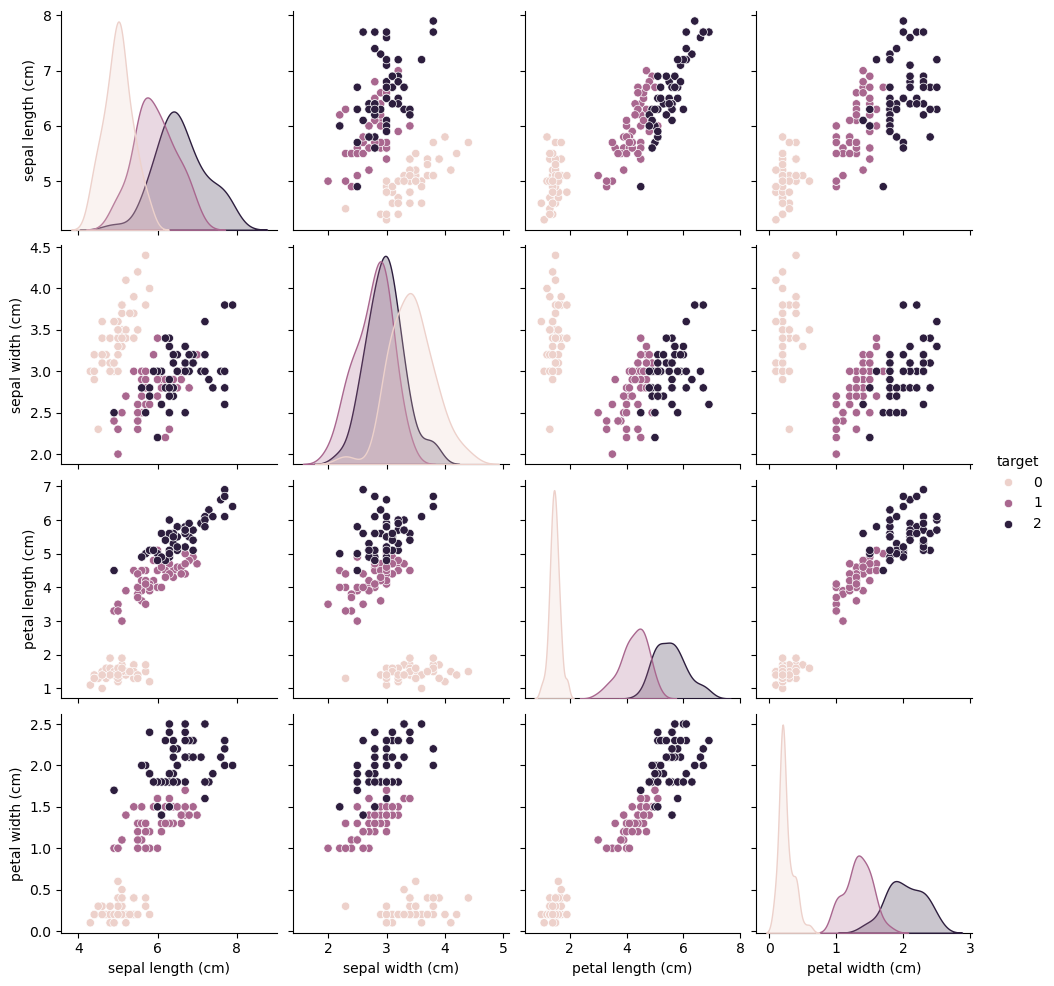

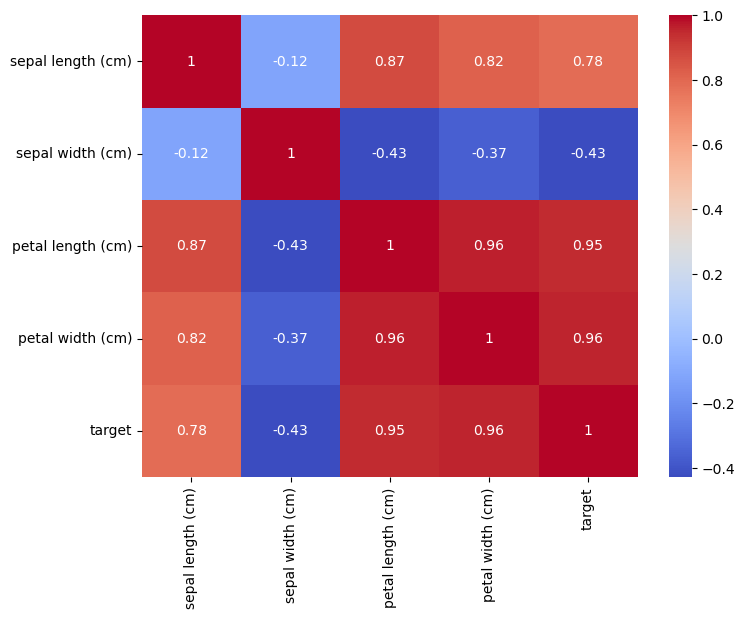

Logistic Regression best parameters: {'C': 1}
SVM best parameters: {'C': 10, 'kernel': 'linear'}
Random Forest best parameters: {'n_estimators': 10}

Logistic Regression 評估指標：
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


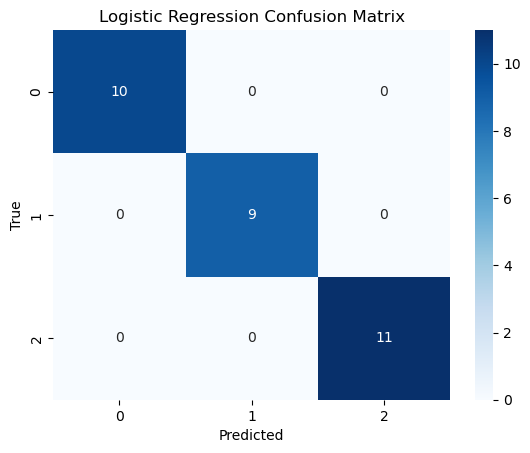


SVM 評估指標：
Accuracy: 0.9666666666666667
Precision: 0.9694444444444444
Recall: 0.9666666666666667
F1-score: 0.9664109121909632


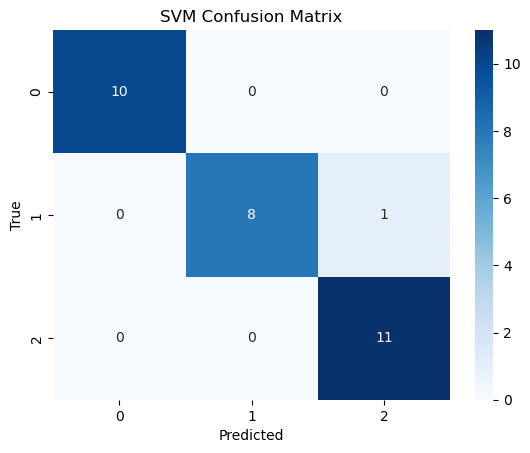


Random Forest 評估指標：
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


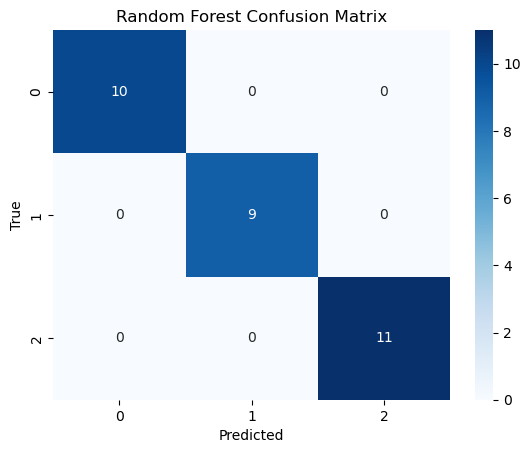

In [1]:
# 機器學習基礎實驗：分類問題的模型訓練與評估

# 步驟 1：數據載入與前處理
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 載入Iris數據集
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# 檢查缺失值
print(df.isnull().sum())

# 標準化
X = df.iloc[:, :-1]
y = df['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 步驟 2：數據可視化與分析
import seaborn as sns
import matplotlib.pyplot as plt

# pairplot 視覺化
sns.pairplot(df, hue='target')
plt.show()

# 特徵相關性矩陣
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# 步驟 3：模型訓練與比較
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 模型定義
models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier()
}

# 超參數設定
params = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
    'Random Forest': {'n_estimators': [10, 50, 100]}
}

best_estimators = {}

# Grid Search
for name in models:
    grid = GridSearchCV(models[name], params[name], cv=5)
    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_
    print(f'{name} best parameters: {grid.best_params_}')

# 步驟 4：模型評估與比較
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    print(f'\n{name} 評估指標：')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred, average='weighted'))
    print('Recall:', recall_score(y_test, y_pred, average='weighted'))
    print('F1-score:', f1_score(y_test, y_pred, average='weighted'))
    
    # confusion matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
